<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit = 0.032562494236005525


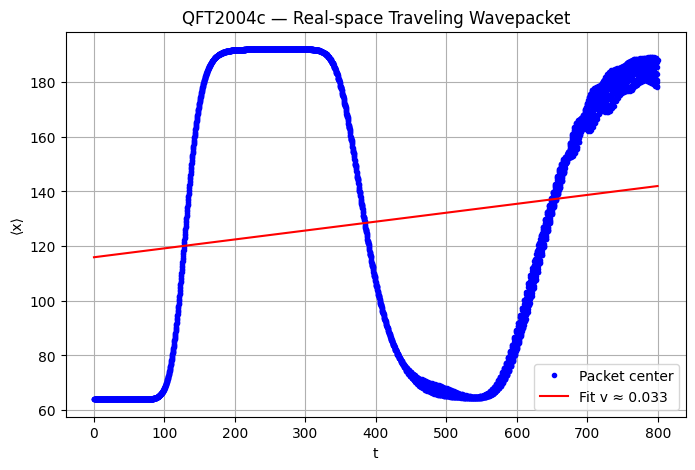

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004c — Real-space Gaussian traveling packet
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Band center (same as before)
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Real-space packet parameters
x = np.arange(N)
x0 = N//4          # initial center
sigma_x = 10.0     # spatial width
A = 1e-3           # amplitude

# -----------------------------
# Build real-space complex packet
# phi_n(0) = A * exp(-(n-x0)^2/(2 sigma_x^2)) * exp(i k0 n)
# -----------------------------
gauss = np.exp(-0.5*((x - x0)/sigma_x)**2)
phase = np.exp(1j * k0 * x)
phi = (A * gauss * phase).astype(np.complex128)

# Zero initial velocity
phi_dot = np.zeros(N, dtype=np.complex128)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Analytic c_eff from dispersion
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Leapfrog evolution + tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 10 == 0:
        density = np.abs(phi)**2
        density_sum = np.sum(density)
        x_mean = np.sum(x * density) / density_sum
        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit velocity
# -----------------------------
coeffs = np.polyfit(times, positions, 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit =", v_fit)

# -----------------------------
# Plot trajectory
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times, np.polyval(coeffs, times), 'r-', label=f"Fit v ≈ {v_fit:.3f}")
plt.title("QFT2004c — Real-space Traveling Wavepacket")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit = 0.01671061110531162


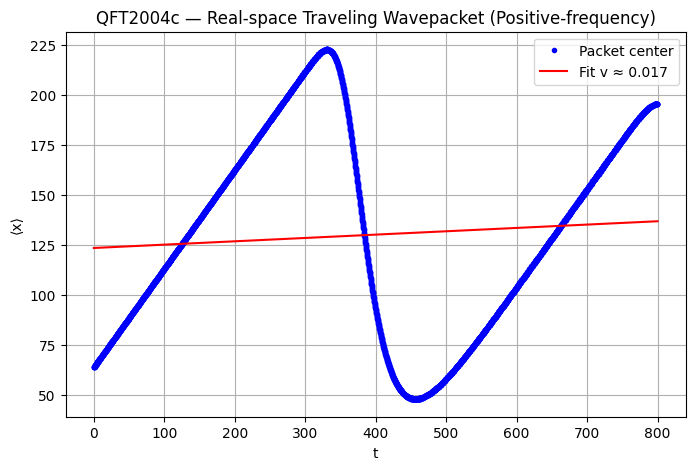

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004c — Real-space Traveling Wavepacket (Positive-frequency IC)
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Band center
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Real-space packet parameters
x = np.arange(N)
x0 = N//4          # initial center
sigma_x = 10.0     # spatial width
A = 1e-3           # amplitude

# -----------------------------
# Dispersion and c_eff
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Build real-space complex packet
# phi(0) = A * exp(-(n-x0)^2/(2 sigma_x^2)) * exp(i k0 n)
# dot(phi)(0) ≈ -i omega(k0) phi(0)  (positive-frequency packet)
# -----------------------------
gauss = np.exp(-0.5*((x - x0)/sigma_x)**2)
phase = np.exp(1j * k0 * x)
phi = (A * gauss * phase).astype(np.complex128)

phi_dot = (-1j * omega_0 * phi).astype(np.complex128)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Leapfrog evolution + tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 10 == 0:
        density = np.abs(phi)**2
        density_sum = np.sum(density)
        x_mean = np.sum(x * density) / density_sum
        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit velocity
# -----------------------------
coeffs = np.polyfit(times, positions, 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit =", v_fit)

# -----------------------------
# Plot trajectory
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times, np.polyval(coeffs, times), 'r-', label=f"Fit v ≈ {v_fit:.3f}")
plt.title("QFT2004c — Real-space Traveling Wavepacket (Positive-frequency)")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit (early-time) = 0.45994759823237275


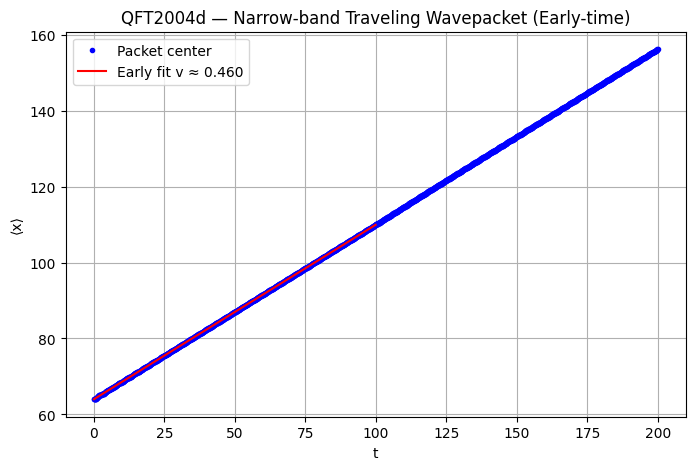

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004d — Narrow-band traveling packet (early-time fit)
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Band center
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 200          # shorter window to focus on early-time drift
steps = int(Tmax/dt)

# Real-space packet parameters
x = np.arange(N)
x0 = N//4           # initial center
sigma_x = 4.0       # narrower packet
A = 1e-3            # amplitude

# -----------------------------
# Dispersion and c_eff
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Real-space complex packet (positive-frequency)
# -----------------------------
gauss = np.exp(-0.5*((x - x0)/sigma_x)**2)
phase = np.exp(1j * k0 * x)
phi = (A * gauss * phase).astype(np.complex128)

phi_dot = (-1j * omega_0 * phi).astype(np.complex128)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Leapfrog evolution + tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 5 == 0:
        density = np.abs(phi)**2
        density_sum = np.sum(density)
        x_mean = np.sum(x * density) / density_sum
        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit velocity on early-time window
# -----------------------------
# Use first half of the data for the fit
cut = len(times)//2
coeffs = np.polyfit(times[:cut], positions[:cut], 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit (early-time) =", v_fit)

# -----------------------------
# Plot trajectory
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times[:cut], np.polyval(coeffs, times[:cut]), 'r-', label=f"Early fit v ≈ {v_fit:.3f}")
plt.title("QFT2004d — Narrow-band Traveling Wavepacket (Early-time)")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()
